In [1]:
!pip install qiskit
!pip install qiskit_aer
!pip install qiskit.providers.aer.noise
!pip install qiskit.providers.aer.noise.errors
!pip install matplotlib pylatexenc
!pip install ipympl
!pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.1 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement qiskit.providers.aer.noise (from versions: none)
ERROR: No matching distribution found for qiskit.providers.aer.noise
ERROR: Could not find a version that satisfies the requirement qiskit.providers.aer.noise.errors (from versions: none)
ERROR: No matching distribution found for qiskit.providers.aer.noise.errors
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=91469112b558fc33217724090babc0ff9f38196b3b3af134b72010103ffa355b
  Stored in directory: /root/.ca

In [2]:

import copy
import math
import warnings
from itertools import combinations, product
from collections import defaultdict

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display

import qiskit
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

try:
    from qiskit_aer import AerSimulator
    Aer = AerSimulator
    HAS_AER = True
except ImportError:
    warnings.warn("Could not import qiskit_aer. AerSimulator functionality will be unavailable.")
    HAS_AER = False

# ==========================================
# 1. SURFACE CODE GENERATOR CLASS
# ==========================================
class SurfaceCode:
    """Implementation of a distance d surface code over T syndrome measurement rounds."""
    def __init__(self, d, T, name=""):
        self.d = d
        self.T = 0
        self.name_label = name # <--- ADD THIS LINE!

        reg_suffix = f"_{name}" if name else ""

        self.data = QuantumRegister(d ** 2, f"data{reg_suffix}")
        self.ancilla = QuantumRegister((d ** 2 - 1), f"ancilla{reg_suffix}")
        self.qubit_registers = {"data", "ancilla"}
        self.output = []
        self.circuit = {}
        self.c_output = ClassicalRegister(d ** 2, f"c_output{reg_suffix}")

        for log in ["0", "1"]:
            self.circuit[log] = QuantumCircuit(self.ancilla, self.data, name=f"{log}{reg_suffix}")

        # Assuming syndrome_measurement and readout are defined elsewhere in your class
        for _ in range(T - 1):
            self.syndrome_measurement()

        if T != 0: # last step
            self.syndrome_measurement(reset=False) #no need next syndrome measurement
            self.readout() # read all data qubits

    def get_circuit_list(self): #change the dictionary "circuit" to list
        return [self.circuit[log] for log in ["0", "1"]]

    def lattice(self):
        d = self.d
        data_string = nx.Graph()
        syndrome_string = nx.Graph()
        for i in range(0, d):
            for j in range(0, d):
                data_string.add_node((i, j))
        for k in range(0, d, 1):
            for i in range(0, d + 1, 1): #if d=3 loop runs from 0 to 3
                for j in range(0, d + 1, 1):
                    if (i + j) % 2 != 0: #to find odd sum
                        if ((i % 2 == 0) and j != d) or ((i % 2 == 1) and (j != 0)):
                            syndrome_string.add_node(((2 * i - 1) / 2, (2 * j - 1) / 2))
                    else:
                        if ((j % 2 == 0) and i != 0) or ((j % 2 == 1) and (i != d)):
                            syndrome_string.add_node(((2 * i - 1) / 2, (2 * j - 1) / 2))
#((i % 2 == 0) and j != d): On even rows ($i=0, 2, ...$), don't place a syndrome qubit on the far right boundary ($j = d$).((i % 2 == 1) and (j != 0)): On odd rows ($i=1, 3, ...$), don't place a syndrome qubit on the far left boundary ($j = 0$).
        return list(syndrome_string.nodes), list(data_string.nodes)

    def connection(self):
        syn_index, data_index = self.lattice() #returns list of syndrome and data qubit's coordinates
        order = []
        for i in range(self.d ** 2 - 1): #syn_index contains d^2-1 qubits for each the coordinates are assigned as variable (r,c)
            r = syn_index[i][0]
            c = syn_index[i][1]

            def get_index(j):#change 2D coordinates to 1D integer i.e if (0,0) is the first element in list then assign it as 0
                for idx in range(len(data_index)):
                    if data_index[idx] == j:
                        return idx

            new = [(r, c)]
            #assigning the data qubits it needs to be connected with (-1 means no connected data qubit)
            if r == -0.5:#top boundary
                new.extend([-1, get_index((r + 0.5, c - 0.5)), -1, get_index((r + 0.5, c + 0.5))])
            elif c == -0.5:#left boundary
                new.extend([-1, get_index((r - 0.5, c + 0.5)), -1, get_index((r + 0.5, c + 0.5))])
            elif r == self.d - 0.5: # bottom boundary
                new.extend([get_index((r - 0.5, c - 0.5)), -1, get_index((r - 0.5, c + 0.5)), -1])
            elif c == self.d - 0.5: # right boundary
                new.extend([get_index((r - 0.5, c - 0.5)), -1, get_index((r + 0.5, c - 0.5)), -1])
            else:
                if (r + c) % 2 == 0:  #usually z stabilizer
                    new.extend([get_index((r - 0.5, c - 0.5)), get_index((r + 0.5, c - 0.5)),
                                get_index((r - 0.5, c + 0.5)), get_index((r + 0.5, c + 0.5))])
                else: #usually x stabilizer
                    new.extend([get_index((r - 0.5, c - 0.5)), get_index((r - 0.5, c + 0.5)),
                                get_index((r + 0.5, c - 0.5)), get_index((r + 0.5, c + 0.5))])
            order.append(new)
        return order # order contains certain no. of lists with coordinates  of syndrome and corresponding connected data qubits

    def syndrome_measurement(self, reset=True, barrier=True):
        # --- NEW CODE: Create a unique name for this round's register ---
        # We use hasattr just in case you ever instantiate without a name
        reg_suffix = f"_{self.name_label}" if hasattr(self, 'name_label') and self.name_label else ""
        register_name = f"round_{self.T}ancilla{reg_suffix}"

        # Create classical register with the unique name
        self.output.append(ClassicalRegister((self.d ** 2 - 1), register_name))
        # ----------------------------------------------------------------

        for log in ["0", "1"]:
            self.circuit[log].add_register(self.output[-1])
            order = self.connection()
            for j in range(1, 5):
                for i in range(len(order)):
                    k = self.data[order[i][j]] #data qubit
                    l = self.ancilla[i] #syndrome qubit
                    if (order[i][0][0] + order[i][0][1]) % 2 == 0:
                        if j == 1: self.circuit[log].h(l) # Before the CNOTs
                        if order[i][j] != -1: self.circuit[log].cx(l, k)
                        if j == 4: self.circuit[log].h(l) # After all 4 CNOTs
                    else:
                        if order[i][j] != -1: self.circuit[log].cx(k, l)
                if barrier: self.circuit[log].barrier()

            for j in range(self.d ** 2 - 1):
                if (order[j][0][0] + order[j][0][1]) % 2 == 1: # if it is Z stabilizer
                    self.circuit[log].measure(self.ancilla[j], self.output[self.T][j]) #do measuremnt of ancilla's and save it to register corresponding to this round in output
                    if reset: self.circuit[log].reset(self.ancilla[j])
            self.circuit[log].barrier()

            for j in range(self.d ** 2 - 1):
                if (order[j][0][0] + order[j][0][1]) % 2 == 0: # if it is X stabilizer
                    self.circuit[log].measure(self.ancilla[j], self.output[self.T][j])
                    if reset: self.circuit[log].reset(self.ancilla[j])
        self.T += 1 #increment of measurment round
    def readout(self):
        for log in ["0", "1"]:
            self.circuit[log].add_register(self.c_output)
            for i in range(self.d ** 2):
                self.circuit[log].measure(self.data[i], self.c_output[i]) #measure data qubit values and store it to output named list

    def process_results(self, raw_results):
        results = list(max(raw_results, key=raw_results.get))
        syn = []
        new = []
        for i in results:
            for j in range(len(i)):
                if i[j] != " ":
                    new.append(int(i[j]))
                else:
                    syn.append(new)
                    new = []
        syn.append(new)
        return syn

    def extract_nodes(self, syn_meas_results):
        """
        Extracts spacetime coordinates of syndrome defects.
        Ignores the initial projection (Round 0) and only logs changes.
        """
        # 1. Separate data readout from syndrome measurements
        # Qiskit outputs classical registers in reverse order of creation.
        # syn_meas_results[0] is the data readout (length 9).
        # syn_meas_results[1:] are the syndromes (Round 2, Round 1, Round 0).
        syndromes_only = syn_meas_results[1:]

        # 2. Put them in chronological order: [Round 0, Round 1, Round 2]
        syndromes_chronological = syndromes_only[::-1]

        processed_results = []

        # 3. Calculate defects (XOR between consecutive rounds)
        # We skip Round 0 because it just establishes the baseline gauge.
        for t in range(1, len(syndromes_chronological)):
            current_round = syndromes_chronological[t]
            prev_round = syndromes_chronological[t-1]

            defects_at_t = []
            for j in range(len(current_round)):
                # If the stabilizer flipped, it's a 1 (defect). If it stayed the same, 0.
                defect = (current_round[j] + prev_round[j]) % 2
                defects_at_t.append(defect)

            processed_results.append(defects_at_t)

        # 4. Map defects to 3D Spacetime Coordinates
        syn_coords, _ = self.lattice()
        error_nodesX, error_nodesZ = [], []

        for t_idx in range(len(processed_results)):
            for j in range(len(processed_results[t_idx])):
                if processed_results[t_idx][j] == 1:
                    r = syn_coords[j][0]
                    c = syn_coords[j][1]

                    # (r+c)%2 == 0 corresponds to the X-stabilizers in your circuit
                    if (r + c) % 2 == 0:
                        error_nodesX.append((t_idx, r, c))
                    else:
                        # Z-stabilizers
                        error_nodesZ.append((t_idx, r, c))

        return error_nodesX, error_nodesZ

In [3]:
import networkx as nx
import math
import copy
from itertools import product, combinations
from collections import defaultdict
import numpy as np

class GraphDecoder:
    """Constructs syndrome graph and runs MWPM decoder."""

    # CHANGE 1: Added hadamard_swapped to the initialization
    def __init__(self, d, T, simulation=False, hadamard_swapped=False):
        self.d = d
        self.T = T
        self.hadamard_swapped = hadamard_swapped # Track if we are in a swapped state
        self.virtual = self._specify_virtual()
        self.S = {"X": nx.Graph(), "Z": nx.Graph()}
        self.simulation = simulation

        if simulation:
            self.code = SurfaceCode(d, T)
            self._make_syndrome_graph_simulate()
        else:
            self._make_syndrome_graph()

    def _specify_virtual(self): #defines the virtual nodes
        virtual = {"X": [], "Z": []}
        for j in range(0, self.d, 2):
            virtual["Z"].append((-1, -0.5, j - 0.5))
            virtual["Z"].append((-1, self.d - 0.5, j + 0.5))
            virtual["X"].append((-1, j + 0.5, -0.5))
            virtual["X"].append((-1, j - 0.5, self.d - 0.5))

        # CHANGE 2: If Hadamards were applied, the physical boundaries of the chip swapped!
        if self.hadamard_swapped:
            virtual["X"], virtual["Z"] = virtual["Z"], virtual["X"]

        return virtual

    def _make_syndrome_graph(self):
        # CHANGE 3: The flood-fill algorithm needs to start at the swapped coordinates
        if self.hadamard_swapped:
            start_nodes = {"Z": (0.5, 1.5), "X": (0.5, 0.5)} # Swapped!
        else:
            start_nodes = {"Z": (0.5, 0.5), "X": (0.5, 1.5)} # Normal

        for error_key in ["X", "Z"]: # space joining
            for t in range(0, self.T):
                start_node = start_nodes[error_key]
                self.S[error_key].add_node(
                    (t,) + start_node, virtual=0, pos=(start_node[1], -start_node[0]),
                    time=t, pos_3D=(start_node[1], -start_node[0], t) #place start nodes corresponding to X and Z in all times(T)
                )
                self.populate_syndrome_graph((t,) + start_node, t, [], error_key, edge_weight=1)#do place rest of the nodes

            syndrome_nodes_t0 = [x for x, y in self.S[error_key].nodes(data=True) if y["time"] == 0] #saves the coordinate of nodes in round 0
            for node in syndrome_nodes_t0:
                space_label = (node[1], node[2])
                for t in range(0, self.T - 1):
                    self.S[error_key].add_edge((t,) + space_label, (t + 1,) + space_label, distance=1) # build nodes in other round using round 0 as blueprint
    def _make_syndrome_graph_simulate(self): #do the same job of making syndrome graph but it injects an error either x or z and look which syn lights and connect those ones
        qc = self.code.circuit["0"]          #foe this it requires 100s of circuits and do simulation several times
        blank_qc = QuantumCircuit()
        for qreg in qc.qregs: blank_qc.add_register(qreg)
        for creg in qc.cregs: blank_qc.add_register(creg)

        error_circuit = {}
        circuit_name = {}
        depth = len(qc)
        for j in range(depth):
            qubits = qc.data[j][1]
            for qubit in qubits:
                for error in ["x", "z"]:
                    temp_qc = copy.deepcopy(blank_qc)
                    temp_qc.name = str((j, qubit, error))
                    temp_qc.data = qc.data[0:j]
                    getattr(temp_qc, error)(qubit)
                    temp_qc.data += qc.data[j : depth + 1]
                    circuit_name[(j, qubit, error)] = temp_qc.name
                    error_circuit[temp_qc.name] = temp_qc

        if not HAS_AER: raise RuntimeError("AerSimulator is required for simulation.")
        simulator = AerSimulator()
        job = simulator.run(list(error_circuit.values()))

        for j in range(depth):
            qubits = qc.data[j][1]
            for qubit in qubits:
                for error in ["x", "z"]:
                    raw_results = {"0": job.result().get_counts(str((j, qubit, error)))}
                    results = self.code.process_results(raw_results["0"])
                    extracted_nodes = self.code.extract_nodes(results)

                    for err_key, nodes in dict(zip(("X", "Z"), extracted_nodes)).items():
                        for node in self.virtual[err_key]:
                            pos_2D = (node[2], -node[1])
                            pos_3D = (*pos_2D, (self.T - 1) / 2)
                            self.S[err_key].add_node(node, virtual=1, pos=pos_2D, time=-1, pos_3D=pos_3D)
                        for node in nodes:
                            pos_2D = (node[2], -node[1])
                            pos_3D = (*pos_2D, node[0])
                            self.S[err_key].add_node(node, virtual=0, pos=pos_2D, time=node[0], pos_3D=pos_3D)
                            candidates = [(-1, node[1] + di, node[2] + dj) for di, dj in product((1, -1), repeat=2)]
                            for virtual in candidates:
                                if virtual in self.virtual[err_key]:
                                    self.S[err_key].add_edge(node, virtual, distance=1)
                        for source, target in combinations(nodes, 2):
                            self.S[err_key].add_edge(source, target, distance=1)

    def populate_syndrome_graph(self, current_node, t, visited_nodes, error_key, edge_weight=1):
        visited_nodes.append(current_node)
        neighbors = []
        i, j = current_node[1], current_node[2]
        neighbors.extend([(i - 1, j - 1), (i + 1, j - 1), (i - 1, j + 1), (i + 1, j + 1)])

        normal_neighbors = [n for n in neighbors if self.valid_syndrome(n, error_key) and (t, n[0], n[1]) not in visited_nodes]
        virtual_neighbors = [n for n in neighbors if (-1, n[0], n[1]) in self.virtual[error_key] and (-1, n[0], n[1]) not in visited_nodes]

        if not normal_neighbors and not virtual_neighbors: return

        for target in normal_neighbors:
            target_node = (t,) + target
            if not self.S[error_key].has_node(target_node):
                self.S[error_key].add_node(target_node, virtual=0, pos=(target[1], -target[0]), time=t, pos_3D=(target[1], -target[0], t))
            self.S[error_key].add_edge(current_node, target_node, distance=edge_weight)

        for target in virtual_neighbors:
            target_node = (-1,) + target
            if not self.S[error_key].has_node(target_node):
                self.S[error_key].add_node(target_node, virtual=1, pos=(target[1], -target[0]), time=-1, pos_3D=(target[1], -target[0], (self.T - 1) / 2))
            self.S[error_key].add_edge(current_node, target_node, distance=edge_weight)

        for target in normal_neighbors: self.populate_syndrome_graph((t,) + target, t, visited_nodes, error_key, edge_weight=1)
        for target in virtual_neighbors: self.populate_syndrome_graph((-1,) + target, t, visited_nodes, error_key, edge_weight=1)

    # ... [Keep _make_syndrome_graph_simulate and populate_syndrome_graph EXACTLY as you had them] ...

    def valid_syndrome(self, node, error_key):#If you didn't have this valid_syndrome check, the populate_syndrome_graph function would keep going forever in all directions.this acts as a stop sign
        i, j = node[0], node[1]

        # CHANGE 4: Tell the "Lattice Guard" to check the opposite map if swapped
        actual_key = error_key
        if self.hadamard_swapped:
            actual_key = "Z" if error_key == "X" else "X"

        if actual_key == "Z": return 0 < i < self.d - 1 and -1 < j < self.d #This allows nodes like $(0.5, 0.5)$ or $(1.5, 2.5)$, but it rejects any node where $i$ is less than $0$ or greater than $2$. This creates a "lane" that is restricted in the $i$-direction but wide in the $j$-direction.
        elif actual_key == "X": return 0 < j < self.d - 1 and -1 < i < self.d#This is the exact opposite. It restricts the $j$-direction but allows a wide range in $i$ . therefore this creates a boundary for the lattice
        return False

    # ... [Keep ALL other methods (make_error_graph, analytic_paths, matching, etc.) EXACTLY the same] ...
    def make_error_graph(self, nodes, error_key, err_prob=None):
        paths = {}
        virtual_dict = nx.get_node_attributes(self.S[error_key], "virtual")
        time_dict = nx.get_node_attributes(self.S[error_key], "time")
        error_graph = nx.Graph()
        nodes += self.virtual[error_key]

        for node in nodes:
            if not error_graph.has_node(node):
                error_graph.add_node(node, virtual=virtual_dict[node], pos=(node[2], -node[1]),
                                     time=time_dict[node], pos_3D=(node[2], -node[1], time_dict[node]))

        for source, target in combinations(nodes, 2):
            distance = int(nx.shortest_path_length(self.S[error_key], source, target, weight="distance"))
            deg, path = self._path_degeneracy(source, target, error_key)
            paths[(source, target)] = path
            if err_prob: distance = distance - math.log(deg)/(math.log1p(-err_prob) - math.log(err_prob))
            distance = -distance
            error_graph.add_edge(source, target, weight=distance)

        if self.simulation: return error_graph
        return error_graph, paths

    def analytic_paths(self, matches, error_key):
        analytic_decoder = GraphDecoder(self.d, self.T)
        paths = {}
        for (source,target) in matches:
            _, path = analytic_decoder._path_degeneracy(source[:3],target[:3], error_key)
            paths[(source[:3], target[:3])] = path
        return paths

    def _path_degeneracy(self, a, b, error_key):
        if error_key == "X": subgraph = self.S["X"]
        elif error_key == "Z": subgraph = self.S["Z"]
        else: raise nx.exception.NodeNotFound("error_key must be X or Z")

        shortest_paths = list(nx.all_shortest_paths(subgraph, a, b, weight="distance"))
        one_path = shortest_paths[0]
        degeneracy = len(shortest_paths)

        source = b if a[0] == -1 else (a if b[0] == -1 else None)
        target = a if a[0] == -1 else (b if b[0] == -1 else None)

        if source:
            shortest_distance = nx.shortest_path_length(subgraph, a, b, weight="distance")
            for node in self.virtual[error_key]:
                distance = nx.shortest_path_length(subgraph, source, node, weight="distance")
                if distance == shortest_distance and node != target:
                    degeneracy += len(list(nx.all_shortest_paths(subgraph, source, node, weight="distance")))
        return degeneracy, one_path

    def matching_graph(self, error_graph, error_key):
        time_dict = nx.get_node_attributes(self.S[error_key], "time")
        subgraph = nx.Graph()
        syndrome_nodes = [x for x, y in error_graph.nodes(data=True) if y["virtual"] == 0]
        virtual_nodes = [x for x, y in error_graph.nodes(data=True) if y["virtual"] == 1]

        for node in syndrome_nodes:
            if not subgraph.has_node(node):
                subgraph.add_node(node, virtual=0, pos=(node[2], -node[1]), time=time_dict[node], pos_3D=(node[2], -node[1], time_dict[node]))
        for source, target in combinations(syndrome_nodes, 2):
            subgraph.add_edge(source, target, weight=error_graph[source][target]["weight"])

        for source in syndrome_nodes:
            potential_virtual = {target: error_graph[source][target]["weight"] for target in virtual_nodes}
            nearest_virtual = max(potential_virtual, key=potential_virtual.get)
            paired_virtual = nearest_virtual + source
            subgraph.add_node(paired_virtual, virtual=1, pos=(nearest_virtual[2], -nearest_virtual[1]), time=-1, pos_3D=(nearest_virtual[2], -nearest_virtual[1], -1))
            subgraph.add_edge(source, paired_virtual, weight=potential_virtual[nearest_virtual])

        paired_virtual_nodes = [x for x, y in subgraph.nodes(data=True) if y["virtual"] == 1]
        for source, target in combinations(paired_virtual_nodes, 2):
            subgraph.add_edge(source, target, weight=0)
        return subgraph

    def matching(self, matching_graph, error_key):
        matches = nx.max_weight_matching(matching_graph, maxcardinality=True)
        return [(s, t) for (s, t) in matches if not (len(s) > 3 and len(t) > 3)]

    def calculate_qubit_flips(self, matches, paths, error_key):
        physical_qubit_flips = {}
        for (source, target) in matches:
            if len(source) > 3: source = source[:3]
            if len(target) > 3: target = target[:3]
            if (source, target) not in paths: source, target = target, source

            path = paths[(source, target)]
            for i in range(0, len(path) - 1):
                start, end = path[i], path[i + 1]
                if start[1:] != end[1:]:
                    time = start[0] if start[0] != -1 else end[0]
                    physical_qubit = (time, (start[1] + end[1]) / 2, (start[2] + end[2]) / 2)
                    physical_qubit_flips[physical_qubit] = (physical_qubit_flips.get(physical_qubit, 0) + 1) % 2
        return {x: error_key for x, y in physical_qubit_flips.items() if y == 1}

    def net_qubit_flips(self, flips_x, flips_z):
        flipsx = {flip: "X" for flip, _ in flips_x.items() if flip not in flips_z}
        flipsz = {flip: "Z" for flip, _ in flips_z.items() if flip not in flips_x}
        flipsy = {flip: "Y" for flip, _ in flips_x.items() if flip in flips_z}
        flips = {**flipsx, **flipsy, **flipsz}

        individual_flips = defaultdict(dict)
        for flip, error_key in flips.items():
            individual_flips[flip[1:]][flip[0]] = error_key

        paulis = {"X": np.array([[0, 1], [1, 0]]), "Y": np.array([[0, -1j], [1j, 0]]),
                  "Z": np.array([[1, 0], [0, -1]]), "I": np.array([[1, 0], [0, 1]])}
        physical_qubit_flips = {}
        for qubit_loc, flip_record in individual_flips.items():
            net_error = paulis["I"]
            for time, error in sorted(flip_record.items(), key=lambda item: item[0]):
                net_error = net_error.dot(paulis[error])
            physical_qubit_flips[qubit_loc] = net_error

        return {x: y for x, y in physical_qubit_flips.items() if not np.array_equal(y, paulis["I"])}

    def graph_2D(self, G, edge_label):
        pos = nx.get_node_attributes(G, "pos")
        nx.draw_networkx(G, pos)
        labels = nx.get_edge_attributes(G, edge_label)
        labels = {x: round(y, 3) for (x, y) in labels.items()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
        plt.show()

    def graph_3D(self, G, edge_label, angle=[-116, 22]):
        import matplotlib.pyplot as plt

        pos_3D = nx.get_node_attributes(G, "pos_3D")
        colors = {x: plt.cm.plasma((y["time"] + 1) / self.T) for x, y in G.nodes(data=True)}

        with plt.style.context(("ggplot")):
            # Slightly smaller figsize so it fits nicely on modern screens
            fig = plt.figure(figsize=(12, 8))

            # THE FIX: Modern way to initialize a 3D axis in Matplotlib
            ax = fig.add_subplot(111, projection='3d')

            for node in G.nodes():
                xi, yi, zi = pos_3D[node]
                ax.scatter(xi, yi, zi, color=colors[node], s=120 * (1 + G.degree(node)), edgecolors="k", alpha=0.8)
                ax.text(xi, yi, zi, str(node), fontsize=10)

            for src, tgt in G.edges():
                x_1, y_1, z_1 = pos_3D[src]
                x_2, y_2, z_2 = pos_3D[tgt]
                ax.plot([x_1, x_2], [y_1, y_2], [z_1, z_2], color="black", alpha=0.5)

                # Midpoint for the edge weights
                mid_x = (x_1 + x_2) / 2
                mid_y = (y_1 + y_2) / 2
                mid_z = (z_1 + z_2) / 2
                weight = round(G[src][tgt].get(edge_label, 0), 2)
                ax.text(mid_x, mid_y, mid_z, str(weight), fontsize=10, color="blue")

            ax.view_init(angle[1], angle[0])
            ax.set_axis_off()

            # Make background transparent
            ax.xaxis.pane.fill = False
            ax.yaxis.pane.fill = False
            ax.zaxis.pane.fill = False
            ax.xaxis.pane.set_edgecolor("w")
            ax.yaxis.pane.set_edgecolor("w")
            ax.zaxis.pane.set_edgecolor("w")

        plt.show()

--- Running Single Iteration for Distance d = 5 ---
Building Depolarizing Noise Model...
Running simulation...

Decoding...

--- Visualizing X-Type Error Processing ---
Graph 1: The X-Error Graph (Close the pop-up window to continue...)


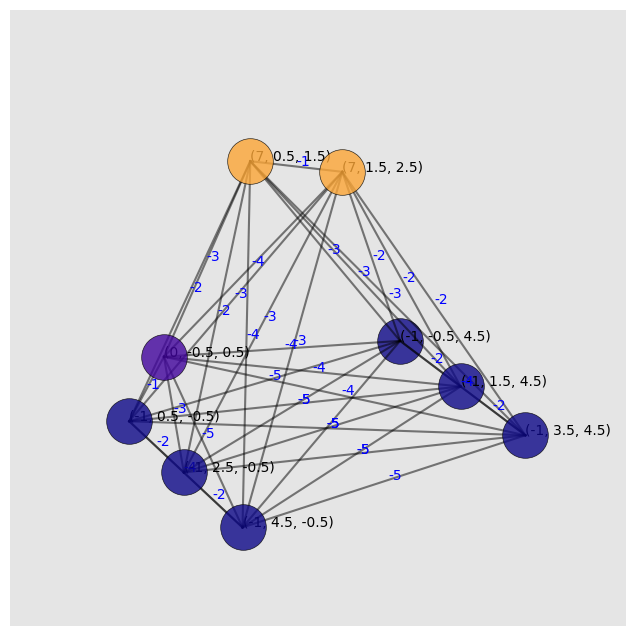

Graph 2: The X-Matching Graph (Close the pop-up window to continue...)


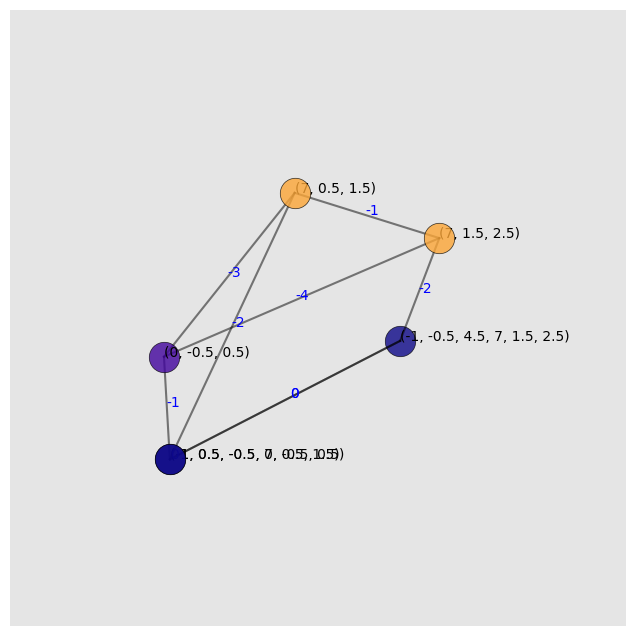


--- Visualizing Z-Type Error Processing ---
Graph 3: The Z-Error Graph (Close the pop-up window to continue...)


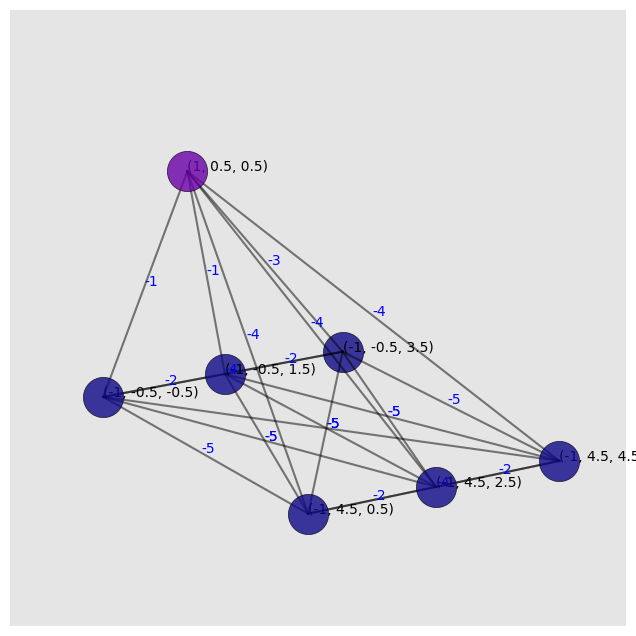

Graph 4: The Z-Matching Graph (Close the pop-up window to continue...)


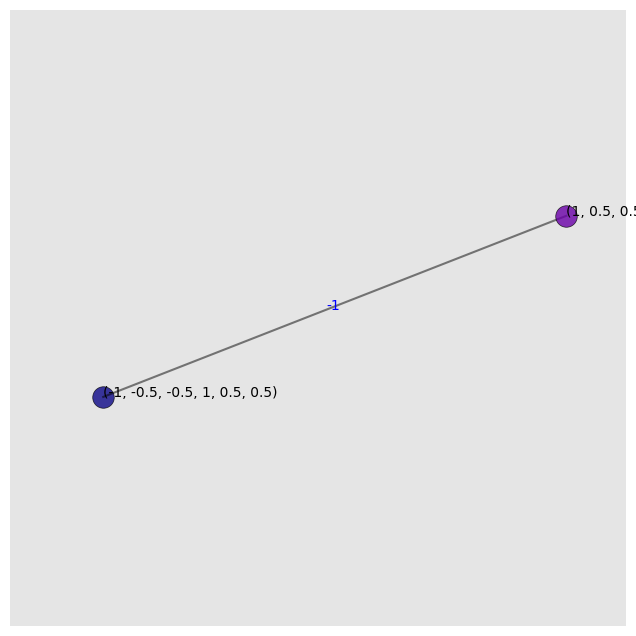


=== FINAL RESULTS ===
=> DECODED STATE: Logical |0>
=> ORACLE RESULT: CONSTANT (Correct)


In [6]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.noise.errors import depolarizing_error
from qiskit.compiler import transpile
from qiskit import QuantumCircuit
import random

# ==========================================
# IMPORT YOUR CUSTOM CLASSES HERE
# (e.g., from your_library import SurfaceCode, GraphDecoder)
# ==========================================

# ==========================================
# 0. THE CRITICAL BUG FIX (Monkey-Patch)
# ==========================================
def fixed_process_results(self, raw_results):
    most_freq_str = max(raw_results, key=raw_results.get)
    syn = []
    for chunk in most_freq_str.split(" "):
        reversed_chunk = [int(c) for c in chunk[::-1]]
        syn.append(reversed_chunk)
    return syn

SurfaceCode.process_results = fixed_process_results

# ==========================================
# 1. INITIALIZE MASTER CIRCUIT & NOISE
# ==========================================
d = 5  # Set your desired distance for this single run
rounds_per_phase = d

print(f"--- Running Single Iteration for Distance d = {d} ---")

patch_A = SurfaceCode(d, 0, "A")
patch_B = SurfaceCode(d, 0, "B")

master_qc = QuantumCircuit(patch_A.data, patch_A.ancilla, patch_B.data, patch_B.ancilla)
trash_A = QuantumCircuit(patch_A.data, patch_A.ancilla)
trash_B = QuantumCircuit(patch_B.data, patch_B.ancilla)

patch_A.circuit["0"] = master_qc
patch_A.circuit["1"] = trash_A
patch_B.circuit["0"] = trash_B
patch_B.circuit["1"] = master_qc

# Initialize Patch B to Logical |1>
for q in patch_B.data: master_qc.x(q)
master_qc.barrier()

print("Building Depolarizing Noise Model...")
noise_model = NoiseModel()
p_1q = 0.0001
p_2q = 0.001

error_1q = depolarizing_error(p_1q, 1)
error_2q = depolarizing_error(p_2q, 2)

noise_model.add_all_qubit_quantum_error(error_1q, ['id', 'h', 'x', 'z'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

simulator = AerSimulator(method="stabilizer")

# ==========================================
# 2. CIRCUIT EXECUTION
# ==========================================
# Baseline Syndrome Extraction
for _ in range(rounds_per_phase):
    patch_A.syndrome_measurement(reset=True)
    patch_B.syndrome_measurement(reset=True)

# The Deutsch Algorithm (Constant: f(x) = 0)
for q in patch_A.data: master_qc.h(q)
for q in patch_B.data: master_qc.h(q)
master_qc.barrier()

# Apply Identity (Constant Oracle)
master_qc.barrier()

for q in patch_A.data: master_qc.h(q)
for q in patch_B.data: master_qc.h(q)
master_qc.barrier()

# Final Syndrome & Readout
for _ in range(rounds_per_phase - 1):
    patch_A.syndrome_measurement(reset=True)
    patch_B.syndrome_measurement(reset=True)

patch_A.syndrome_measurement(reset=False)
patch_A.readout()
patch_B.syndrome_measurement(reset=False)
patch_B.readout()

# Simulation
print("Running simulation...")
job = simulator.run(transpile(master_qc, simulator), shots=1, noise_model=noise_model)
raw_counts = job.result().get_counts()

most_frequent_result = max(raw_counts, key=raw_counts.get)
chunks = most_frequent_result.split(" ")

cregs_reversed = list(reversed(master_qc.cregs))
chunk_map = {creg.name: chunk.zfill(creg.size) for creg, chunk in zip(cregs_reversed, chunks)}

string_A_chunks = [chunk_map[patch_A.c_output.name]] + [chunk_map[reg.name] for reg in reversed(patch_A.output)]
string_A = " ".join(string_A_chunks)

syn_history_A = patch_A.process_results({string_A: 1})

# ==========================================
# 3. ERROR CORRECTION & 3D GRAPH VISUALIZATION
# ==========================================
print("\nDecoding...")
decoder_A = GraphDecoder(d, patch_A.T)
error_nodesX_A, error_nodesZ_A = patch_A.extract_nodes(syn_history_A)

print("\n--- Visualizing X-Type Error Processing ---")
if error_nodesX_A:
    error_graph_X_A, paths_X_A = decoder_A.make_error_graph(error_nodesX_A, "X")
    print("Graph 1: The X-Error Graph (Close the pop-up window to continue...)")
    decoder_A.graph_3D(error_graph_X_A, edge_label="weight")

    matching_graph_X_A = decoder_A.matching_graph(error_graph_X_A, "X")
    print("Graph 2: The X-Matching Graph (Close the pop-up window to continue...)")
    decoder_A.graph_3D(matching_graph_X_A, edge_label="weight")

    matches_X_A = decoder_A.matching(matching_graph_X_A, "X")
    flips_X_A = decoder_A.calculate_qubit_flips(matches_X_A, paths_X_A, "X")
else:
    print("No X-type errors to visualize.")
    flips_X_A = {}

print("\n--- Visualizing Z-Type Error Processing ---")
if error_nodesZ_A:
    error_graph_Z_A, paths_Z_A = decoder_A.make_error_graph(error_nodesZ_A, "Z")
    print("Graph 3: The Z-Error Graph (Close the pop-up window to continue...)")
    decoder_A.graph_3D(error_graph_Z_A, edge_label="weight")

    matching_graph_Z_A = decoder_A.matching_graph(error_graph_Z_A, "Z")
    print("Graph 4: The Z-Matching Graph (Close the pop-up window to continue...)")
    decoder_A.graph_3D(matching_graph_Z_A, edge_label="weight")

    matches_Z_A = decoder_A.matching(matching_graph_Z_A, "Z")
    flips_Z_A = decoder_A.calculate_qubit_flips(matches_Z_A, paths_Z_A, "Z")
else:
    print("No Z-type errors to visualize.")
    flips_Z_A = {}

final_corrections_A = decoder_A.net_qubit_flips(flips_Z_A, flips_X_A)

# ==========================================
# 4. LOGICAL READOUT EVALUATION
# ==========================================
raw_data_bits_A = syn_history_A[0]
corrected_data_bits_A = list(raw_data_bits_A)

for qubit_coord, pauli_matrix in final_corrections_A.items():
    r, c = int(qubit_coord[0]), int(qubit_coord[1])
    idx = r * d + c
    if pauli_matrix[0][0] == 0:  # X correction
        corrected_data_bits_A[idx] = (corrected_data_bits_A[idx] + 1) % 2

logical_Z_parity = sum([corrected_data_bits_A[r * d + 0] for r in range(d)]) % 2

print("\n=== FINAL RESULTS ===")
if logical_Z_parity == 0:
    print("=> DECODED STATE: Logical |0>")
    print("=> ORACLE RESULT: CONSTANT (Correct)")
else:
    print("=> DECODED STATE: Logical |1>")
    print("=> ORACLE RESULT: BALANCED (Incorrect)")